# More targeted power spectrum normalization tests

In [1]:
from powerbox import get_power, PowerBox
import numpy as np
import matplotlib.pyplot as plt
import py21cmsense as sense
from py21cmsense.conversions import f2z, z2f
from astropy import units as un
from astropy.cosmology import Planck18, z_at_value
from astropy.cosmology.units import with_H0
from tuesday.core import compute_thermal_rms_uvgrid

In https://reionization.org/manual_uploads/HERA113_power_spectrum_normalisation_and_sensitivity.pdf I have the following working:

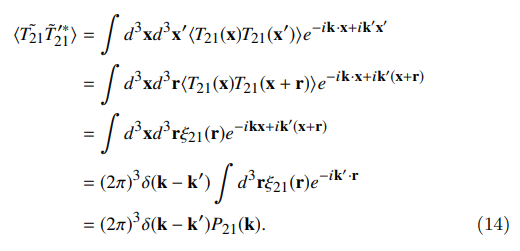

with this definition of the cosmological fourier transform:

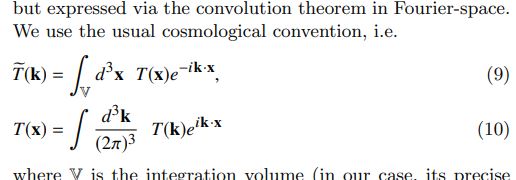

Notice that the units here are correct. $\tilde{T}(k)$ has units of ${\rm mK}{\rm Mpc}^3$ and $P_{21}$ has units of ${\rm mK}^2 {\rm Mpc}^3$. The latter point bears a little more thought -- while $\langle \tilde{T} \tilde{T} \rangle$ has units ${\rm mK}^2 {\rm Mpc}^6$, the dirac delta has units of volume, so that this cancels. But *which* volume is it? This becomes apparent if we discretize as if we have a simulation box. The relevant properties of the dirac delta here are that it integrates to unity and only has a value at $k_i = k'_i$. Therefore, it should be the Kronecker delta with a normalization such that the integral over $\vec{k}$ is unity, i.e.

$$
    \delta)\vec{k} - \vec{k}') \rightarrow \delta_{\vec{k},\vec{k'}} / V_k,
$$

where $V_k$ is the "volume" of a Fourier-space cell. Given a box with $N$ cells per side and boxlength $L$, i.e. cell size of $\Delta x=L/N$ we have that 

$$
    V_k = (2\pi/\Delta x)^3.
$$


Thus, we have 

$$
    \tilde{T}_{qpt}(k) = (\Delta x)^3 \sum_{jkl} T(x_{jkl}) e^{-i(qj + pk + tl)}
$$

So that 

$$
    \langle \tilde{T} \tilde{T}' \rangle = (2\pi)^3 \delta_{k, k'} (\Delta x/(2\pi))^3 P(k).
$$

Turning this around we have 

$$
    P(\vec{k}) = {\rm Var}(\tilde{T}(k)) / (\Delta x)^3
$$

The iFFT in `numpy` is defined as:

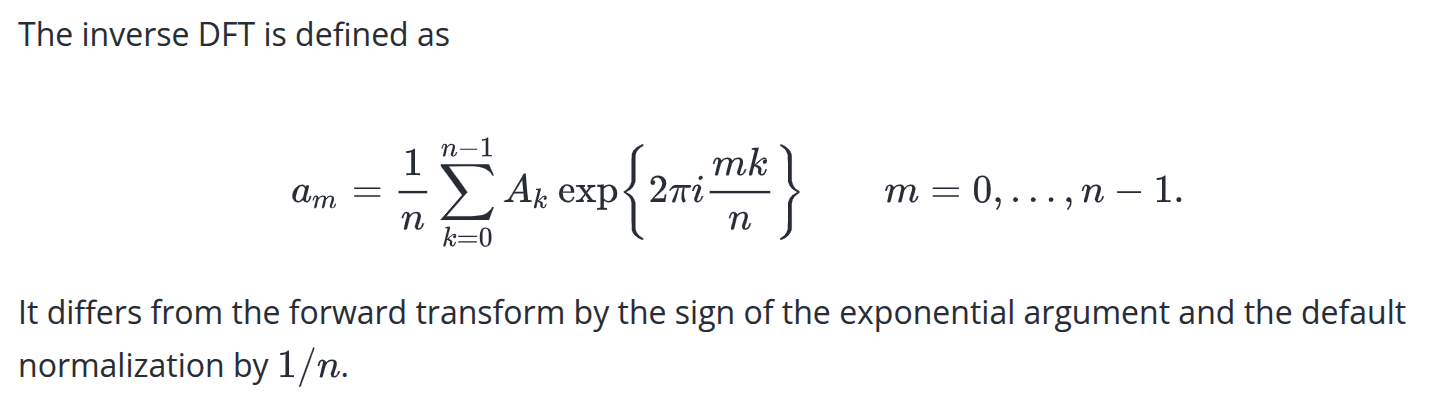

In [2]:
def make_hermitian_for_irfft(x):
    n = len(x)
    
    x[0, 0] = np.real(x[0, 0])
    print('1', np.any(np.isnan(x)))
    if n%2!=0:
        x[1:n//2+1, 0] = np.conj(x[-1:n//2:-1,0])
    print('2', np.any(np.isnan(x)))
    if n%2==0:
        x[1:n//2+1, 0] = np.conj(x[-1:n//2-1:-1,0])
        x[n//2, 0] = np.real(x[n//2, 0])
        print('3', np.any(np.isnan(x)))
        x[0,-1] = np.real(x[0, -1])
        x[1:n//2+1, -1] = np.conj(x[-1:n//2-1:-1,-1])
        x[n//2, -1] = np.real(x[n//2, -1])
        print('4', np.any(np.isnan(x)))

In [3]:
nx = 1000
L = 100 # Mpc

# Start with EXPECTED POWER SPECTRUM, because this is
# what we know from e.g. 21cmSense
expected_power = 15.0

for L in [50, 100, 200]:
    nx = 10*L
    dx = L/nx
    print(f"L = {L}")
    
    pb = PowerBox(N=nx, dim=2, pk=lambda k: expected_power, seed=L, boxlength=L)

    # The Variance of the UV-space field has units mK^2 Mpc^2, following P = Var(T) / dx^2
    trms_uv = np.ones((nx,nx//2 + 1)) * np.sqrt(expected_power * dx**2)
    make_hermitian_for_irfft(trms_uv)
    
    t_uv = np.random.normal(scale=trms_uv/np.sqrt(2)) + 1j*np.random.normal(scale=trms_uv/np.sqrt(2))
    t_uv_pb = pb.delta_k()

    # take this out eventually... 
    t_uv_re = t_uv_pb * (dx**4 * nx**2)  # full uv plane but normalized like I want it
    
    print('variance of uv field: ', np.mean(np.abs(t_uv)**2))
    print('variance of uv field (re): ', np.mean(np.abs(t_uv_re)**2))
    
    print('variance of uv field (pb): ', np.mean(np.abs(t_uv_pb)**2))

          
    trms_img = np.fft.irfft2(t_uv, s=(nx,nx)) * nx / dx**2
    trms_img_re = np.fft.ifft2(t_uv_re) * (1 / dx**4)
    trms_img_pb = pb.delta_x()

    print('variance of real-space field: ', np.var(trms_img))
    print('variance of real-space field (re): ', np.var(trms_img_re))

    print('variance of real-space field (pb): ', np.var(trms_img_pb))
    
    p, k, *_ = get_power(trms_img, boxlength=L)

    p_re, k_re, *_ = get_power(trms_img_re, boxlength=L)
    p_pb, k_pb, *_ = get_power(trms_img_pb, boxlength=L)
    
    print('mean to expected power: ', np.mean(p)/expected_power)
    print('mean to expected power (re): ', np.mean(p_re)/expected_power)

    print('mean to expected power (pb): ', np.mean(p_pb)/expected_power)
    print('-----------')
    print()

L = 50
1 False
2 False
3 False
4 False
variance of uv field:  0.14953302014423878
variance of uv field (re):  3.743152321583152
variance of uv field (pb):  0.005989043714533043
variance of real-space field:  1492.7580651994106
variance of real-space field (re):  1497.259522214531
variance of real-space field (pb):  1494.3689670316062


/home/steven/Documents/work/21cmfast/tuesday/.venv/lib/python3.12/site-packages/powerbox/tools.py:256: FutureWarning: In the future, bins will be generated by default up to the smallest length over any dimension, instead of the largest magnitude for the box.Set bins_upto_boxlen to silence this warning.
  bins = _getbins(bins, coord_mags, log_bins, bins_upto_boxlen=bins_upto_boxlen)


mean to expected power:  0.991446354311289
mean to expected power (re):  1.0002332774143476
mean to expected power (pb):  0.9942862521338475
-----------

L = 100
1 False
2 False
3 False
4 False
variance of uv field:  0.14996254379608137
variance of uv field (re):  14.928472345398147
variance of uv field (pb):  0.0014928472345398138
variance of real-space field:  1498.1702046597486
variance of real-space field (re):  1492.8368132259773
variance of real-space field (pb):  1491.174139543818
mean to expected power:  0.9959187635744616
mean to expected power (re):  0.9991231540368132
mean to expected power (pb):  0.9948939016645535
-----------

L = 200
1 False
2 False
3 False
4 False
variance of uv field:  0.1500819237492396
variance of uv field (re):  59.99697573975824
variance of uv field (pb):  0.0003749810983734892
variance of real-space field:  1500.0816498539004
variance of real-space field (re):  1499.9234110968914
variance of real-space field (pb):  1499.1365293291185
mean to expect

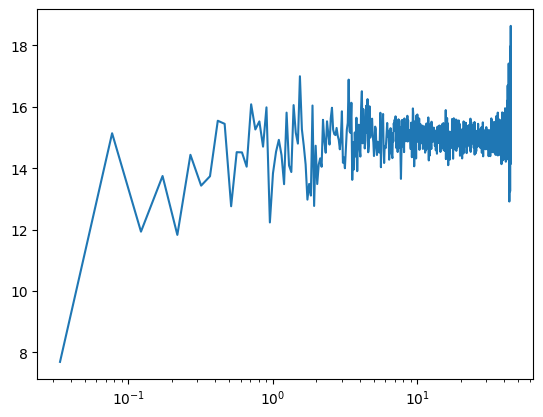

In [4]:
plt.plot(k, p)
plt.xscale('log')

In [5]:
hours_tracking = 1.0 * un.hour
integration_time = 1800 * un.s

zmean = 15.0
freq = 1420 / (1 + zmean) * un.MHz

observatory = sense.Observatory.from_ska(subarray_template="LOW_INNER_R350M_AA4")

# Make an observation
observation = sense.Observation(
    observatory=observatory,
    time_per_day=hours_tracking,
    lst_bin_size=hours_tracking,
    integration_time=integration_time,
    bandwidth=76.0 * un.MHz,
    n_channels=80,
    n_days=int(np.ceil(1000 / hours_tracking.value)),
    tsky_amplitude=60.0 * un.K,  # to be consistent with tools21cm
    tsky_ref_freq=300.0 * un.MHz,
    spectral_index=2.55,
    frequency=freq
)

# baseline_vecs_u = np.tile(observation.ugrid, len(observation.vgrid))
# baseline_vecs_v = np.repeat(observation.vgrid, len(observation.ugrid))

# del observation.observatory.redundant_baseline_groups
# del observation.observatory.redundant_baseline_vectors

# nreq = len(observation.observatory.baselines) // len(baseline_vecs_u) + 1

# baseline_vecs_u = np.tile(baseline_vecs_u, nreq)[:len(observation.observatory.baselines)]
# baseline_vecs_v = np.tile(baseline_vecs_v, nreq)[:len(observation.observatory.baselines)]


# observation.observatory.baselines[:, 0] = baseline_vecs_u / observation.metres_to_wavelengths
# observation.observatory.baselines[:, 1] = baseline_vecs_v / observation.metres_to_wavelengths

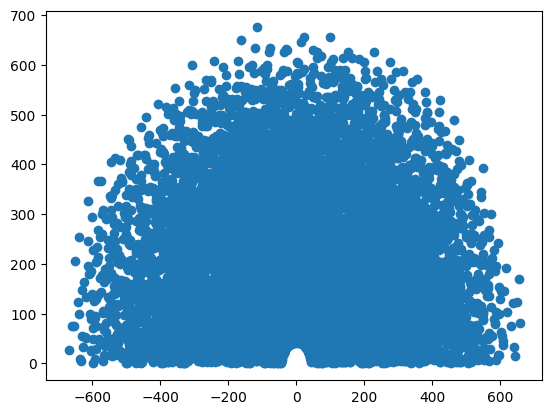

In [6]:
plt.scatter(observation.observatory.baselines[:, 0], observation.observatory.baselines[:, 1])

In [7]:
len(observation.observatory.redundant_baseline_groups)

finding redundancies: 10153ants [00:00, 106939.41ants/s]


10151

In [48]:
# Setup some fake frequencies, similar to a standard observation,
# but regular in comoving distance, like a typical simulation.
min_freq = freq - observation.bandwidth / 2
max_freq = freq + observation.bandwidth / 2
min_z = f2z(max_freq)  # lower edge of first cell
max_z = f2z(min_freq)  # upper edge of last cell

Dz = Planck18.comoving_distance(zmean)

# By equating the Delta u between 21cmSense and Tuesday LC,
# we can compute L:
boxlength = Dz / observatory.beam.uv_resolution(observation.frequency)

# By equating the frequency channel width we can get the box resolution:
nuprime = freq - observation.bandwidth / observation.n_channels
zprime = f2z(nuprime)
boxres = Planck18.comoving_distance(zprime) - Dz
#boxres *= 2  # for shiggles
box_ncell = int(boxlength / boxres)

# Now, we actually want the same *number* of channels as the observation,
# where each has the same comoving size, and this comoving size is given
# by boxres. This will actually mean that the total length of the box
# along the line of sight is larger than the the bandwidth of the observation,
# because channels tend to get smaller in comoving size.
min_dist = Dz - boxres * observation.n_channels / 2
max_dist = Dz + boxres * observation.n_channels / 2

distances = (
    np.arange(
        min_dist.to_value("Mpc"), max_dist.to_value("Mpc"), boxres.to_value("Mpc")
    )
    * un.Mpc
)
nz = len(distances)

lc_redshifts = np.array([z_at_value(Planck18.comoving_distance, d) for d in distances])
lc_freqs = z2f(lc_redshifts)

lc_shape = (box_ncell, box_ncell, nz)

In [49]:
lc_shape

(41, 41, 80)

In [50]:
psense = sense.PowerSpectrum(observation=observation, foreground_model="foreground_free")

In [51]:
ugrid_edges, vgrid_edges, sigma_uv, uv_coverage = compute_thermal_rms_uvgrid(
    observation=observation, freqs=lc_freqs, box_length=boxlength, box_ncells=box_ncell
)

In [52]:
ugrid_edges

array([[-217.19846662, -217.69388883, -218.18931207, ..., -255.34609081,
        -255.84151347, -256.33693559],
       [-206.60341947, -207.07467474, -207.545931  , ..., -242.89018394,
        -243.36143964, -243.83269483],
       [-196.00837232, -196.45546065, -196.90254992, ..., -230.43427708,
        -230.88136581, -231.32845407],
       ...,
       [ 196.00837232,  196.45546065,  196.90254992, ...,  230.43427708,
         230.88136581,  231.32845407],
       [ 206.60341947,  207.07467474,  207.545931  , ...,  242.89018394,
         243.36143964,  243.83269483],
       [ 217.19846662,  217.69388883,  218.18931207, ...,  255.34609081,
         255.84151347,  256.33693559]], shape=(42, 80))

In [53]:
np.abs(ugrid_edges).min()

np.float64(5.297523576217015)

In [54]:
np.abs(observation.ugrid_edges).min()

<Quantity 5.77274362>

In [55]:
observation.ugrid_edges

<Quantity [-213.59151403, -202.04602679, -190.50053954, -178.9550523 ,
           -167.40956505, -155.86407781, -144.31859056, -132.77310332,
           -121.22761607, -109.68212883,  -98.13664158,  -86.59115434,
            -75.04566709,  -63.50017985,  -51.9546926 ,  -40.40920536,
            -28.86371811,  -17.31823087,   -5.77274362,    5.77274362,
             17.31823087,   28.86371811,   40.40920536,   51.9546926 ,
             63.50017985,   75.04566709,   86.59115434,   98.13664158,
            109.68212883,  121.22761607,  132.77310332,  144.31859056,
            155.86407781,  167.40956505,  178.9550523 ,  190.50053954,
            202.04602679,  213.59151403]>

In [56]:
# Only use the uv_coverage for now:

total_intg_time = uv_coverage * observation.n_days * observation.integration_time.to(un.s)

trms = np.ones(total_intg_time.shape) * np.inf * observation.Tsys.unit
mask = total_intg_time > 0
trms[mask] = observation.Tsys.to("K") / np.sqrt(
    2 * observation.bandwidth * total_intg_time[mask]
).to("")


In [57]:
power_per_uv_cell = trms**2 * observation.observatory.beam.b_eff(observation.frequency) * observation.bandwidth * psense.X2Y

In [76]:
# Start with EXPECTED POWER SPECTRUM, because this is
# what we know from e.g. 21cmSense

nx = power_per_uv_cell.shape[0]
L = boxlength.to_value("Mpc")
expected_power = power_per_uv_cell.to_value("mK^2 Mpc^3", with_H0(Planck18.H0))

dx = L/nx
trms_uv = np.sqrt(expected_power * dx**3)

fully_avg_p = 0
for i in range(100):
    # print(f"L = {L}")
    
    # pb = PowerBox(N=nx, dim=2, pk=lambda k: np.mean(expected_power[~np.isinf(expected_power)]), seed=1234, boxlength=L)
    
    # The Variance of the UV-space field has units mK^2 Mpc^2, following P = Var(T) / dx^2
    
    t_uv = np.random.normal(scale=trms_uv/np.sqrt(2)) + 1j*np.random.normal(scale=trms_uv/np.sqrt(2))
    t_uv[~np.isfinite(t_uv)] = 0.0
    
    # print(np.any(np.isnan(t_uv)))
    make_hermitian_for_irfft(t_uv)
    # t_uv_pb = pb.delta_k()
    
    
    # # take this out eventually... 
    # #t_uv_re = t_uv_pb * (dx**4 * nx**2)  # full uv plane but normalized like I want it
    
    # print('variance of uv field: ', np.mean(np.abs(t_uv)**2))
    # #print('variance of uv field (re): ', np.mean(np.abs(t_uv_re)**2))
    
    # print('variance of uv field (pb): ', np.mean(np.abs(t_uv_pb)**2))
    
          
    trms_img = np.fft.irfft2(t_uv, s=(nx,nx), axes=(0,1)) * nx / dx**3
    #trms_img_re = np.fft.ifft2(t_uv_re) * (1 / dx**4)
    # trms_img_pb = pb.delta_x()
    
    # print('variance of real-space field: ', np.var(trms_img))
    # #print('variance of real-space field (re): ', np.var(trms_img_re))
    
    # print('variance of real-space field (pb): ', np.var(trms_img_pb))
    
    
    ## ESTABLISH WEIGHTS FOR AVERAGING THE POWER 
    # weights = uv_coverage**4
    
    # # weights is shape (nx, nx//2 + 1, nchan)
    # # we need to make it shape (nx, nx, nchan) for calculate_ps_lc, so we can just mirror the weights along the second axis:
    # #nx = lc_shape[0]
    # if nx % 2 == 0:
    #     # even case, we need to mirror all but the last point (the Nyquist frequency)
    #     weights = np.concatenate((weights[:,::-1, :], weights[:, 1:-1, :]), axis=1)
    # else:
    #     # odd case, we can mirror all points
    #     weights = np.concatenate((weights[:, ::-1, :], weights[:, 1:, :]), axis=1)
    
    
    
    p, k, _, wght = get_power(trms_img, boxlength=(L, L, nz*dx), res_ndim=0)
    
    #p_re, k_re, *_ = get_power(trms_img_re, boxlength=L)
    # p_pb, k_pb, *_ = get_power(trms_img_pb, boxlength=L)
    
    # print('mean to expected power: ', np.mean(p)/np.mean(expected_power[~np.isinf(expected_power)]))
    # #print('mean to expected power (re): ', np.mean(p_re)/expected_power)
    
    # print('mean to expected power (pb): ', np.mean(p_pb)/np.mean(expected_power[~np.isinf(expected_power)]))
    # print('-----------')
    # print()
    avg_p = inverse_variance_weighted_sum(p, k, kbins)
    fully_avg_p += avg_p

fully_avg_p /= 100

/tmp/ipykernel_16656/2175712352.py:19: RuntimeWarning: invalid value encountered in multiply
  t_uv = np.random.normal(scale=trms_uv/np.sqrt(2)) + 1j*np.random.normal(scale=trms_uv/np.sqrt(2))
/home/steven/Documents/work/21cmfast/tuesday/.venv/lib/python3.12/site-packages/powerbox/tools.py:281: RuntimeWarning: invalid value encountered in divide
  np.bincount(
/tmp/ipykernel_16656/3662136944.py:20: RuntimeWarning: divide by zero encountered in divide
  out[idx] = 1 / np.sqrt(np.sum((4*np.pi**4)/(kk**6 * pp**2)))


1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False
2 False
1 False


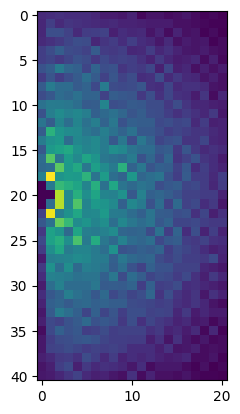

In [77]:
plt.imshow(uv_coverage[:, :, 0])

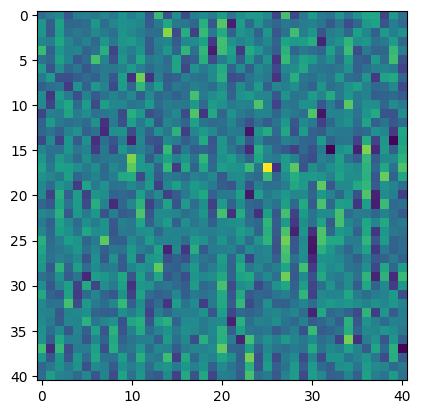

In [78]:
plt.imshow(trms_img[..., 0])

In [79]:
pksense = psense.calculate_sensitivity_1d(thermal=True, sample=False)

In [80]:
from powerbox.tools import _magnitude_grid, _get_binweights

def inverse_variance_weighted_sum(p: np.ndarray, k: list[np.ndarray], kbins, ):
    """average the power p in spherical shells in inverse quadrature"""
    kmag = _magnitude_grid(k)

    indx, bins, sumweights = _get_binweights(
        kmag,
        weights=1,
        bins=kbins,
    )

    out = np.zeros(len(kbins)-1)
    for idx in range(indx.max() + 1):
        mask = indx==idx
        pmask = p.flatten()[mask] > 1e-5
        kk = kmag.flatten()[mask][pmask]
        pp = p.flatten()[mask][pmask]
        
        out[idx] = 1 / np.sqrt(np.sum((4*np.pi**4)/(kk**6 * pp**2)))

    return out

In [81]:
k1d = psense.k1d.to_value("1/Mpc", with_H0(Planck18.H0))
dk = k1d[1] - k1d[0]
kbins = k1d - dk/2
kbins = np.append(kbins, kbins[-1]+dk)

avg_p = inverse_variance_weighted_sum(p, k, kbins)

/home/steven/Documents/work/21cmfast/tuesday/.venv/lib/python3.12/site-packages/powerbox/tools.py:281: RuntimeWarning: invalid value encountered in divide
  np.bincount(
/tmp/ipykernel_16656/3662136944.py:20: RuntimeWarning: divide by zero encountered in divide
  out[idx] = 1 / np.sqrt(np.sum((4*np.pi**4)/(kk**6 * pp**2)))


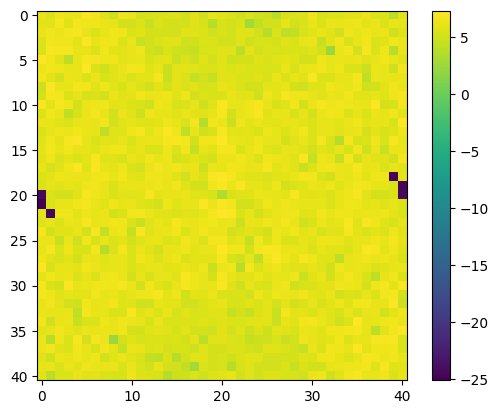

In [82]:
plt.imshow(np.log10(p[:, :, 0]))
plt.colorbar()

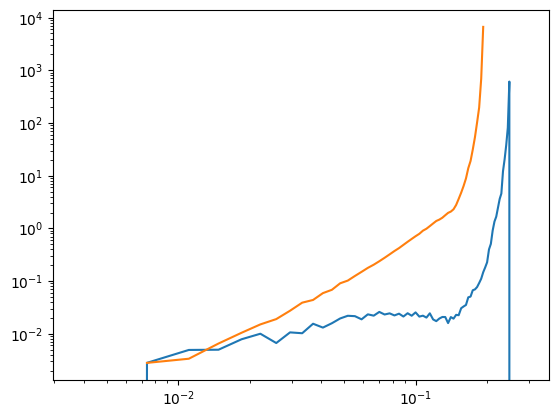

In [83]:
plt.plot(k1d, fully_avg_p)#/ np.sqrt(wght))
plt.plot(psense.k1d.to_value("1/Mpc", with_H0(Planck18.H0)), pksense.to_value("mK^2"))
#plt.plot(k, k**3)
plt.xscale('log')
plt.yscale('log')

### The thing that works for 2D is below...

In [178]:
nx = 1000
L = 100 # Mpc

# Start with EXPECTED POWER SPECTRUM, because this is
# what we know from e.g. 21cmSense
expected_power = 15.0

for L in [50, 100, 200]:
    nx = 10*L
    dx = L/nx
    print(f"L = {L}")
    
    pb = PowerBox(N=nx, dim=2, pk=lambda k: expected_power, seed=L, boxlength=L)

    # The Variance of the UV-space field has units mK^2 Mpc^2, following P = Var(T) / dx^2
    trms_uv = np.ones((nx,nx//2 + 1)) * np.sqrt(expected_power * dx**2)
    
    t_uv = np.random.normal(scale=trms_uv/np.sqrt(2)) + 1j*np.random.normal(scale=trms_uv/np.sqrt(2))
    make_hermitian_for_irfft(t_uv)
    
    t_uv_pb = pb.delta_k()

    # take this out eventually... 
    t_uv_re = t_uv_pb * (dx**4 * nx**2)  # full uv plane but normalized like I want it
    
    print('variance of uv field: ', np.mean(np.abs(t_uv)**2))
    print('variance of uv field (re): ', np.mean(np.abs(t_uv_re)**2))
    
    print('variance of uv field (pb): ', np.mean(np.abs(t_uv_pb)**2))

          
    trms_img = np.fft.irfft2(t_uv, s=(nx,nx)) * nx / dx**2
    trms_img_re = np.fft.ifft2(t_uv_re) * (1 / dx**4)
    trms_img_pb = pb.delta_x()

    print('variance of real-space field: ', np.var(trms_img))
    print('variance of real-space field (re): ', np.var(trms_img_re))

    print('variance of real-space field (pb): ', np.var(trms_img_pb))
    
    p, k, *_ = get_power(trms_img, boxlength=L)

    p_re, k_re, *_ = get_power(trms_img_re, boxlength=L)
    p_pb, k_pb, *_ = get_power(trms_img_pb, boxlength=L)
    
    print('mean to expected power: ', np.mean(p)/expected_power)
    print('mean to expected power (re): ', np.mean(p_re)/expected_power)

    print('mean to expected power (pb): ', np.mean(p_pb)/expected_power)
    print('-----------')
    print()

L = 50
variance of uv field:  0.14983910966265587
variance of uv field (re):  3.743152321583152
variance of uv field (pb):  0.005989043714533043
variance of real-space field:  1498.419969009606
variance of real-space field (re):  1497.259522214531
variance of real-space field (pb):  1494.3689670316062


/home/steven/Documents/work/21cmfast/tuesday/.venv/lib/python3.12/site-packages/powerbox/tools.py:312: FutureWarning: In the future, bins will be generated by default up to the smallest length over any dimension, instead of the largest magnitude for the box.Set bins_upto_boxlen to silence this warning.
  bins = _getbins(bins, coord_mags, log_bins, bins_upto_boxlen=bins_upto_boxlen)


mean to expected power:  0.9966298680269186
mean to expected power (re):  1.0002332774143476
mean to expected power (pb):  0.9942862521338475
-----------

L = 100
variance of uv field:  0.14997329974822673
variance of uv field (re):  14.928472345398147
variance of uv field (pb):  0.0014928472345398138
variance of real-space field:  1499.733932278468
variance of real-space field (re):  1492.8368132259773
variance of real-space field (pb):  1491.174139543818
mean to expected power:  0.9999009381079507
mean to expected power (re):  0.9991231540368132
mean to expected power (pb):  0.9948939016645535
-----------

L = 200
variance of uv field:  0.15008361123041727
variance of uv field (re):  59.99697573975824
variance of uv field (pb):  0.0003749810983734892
variance of real-space field:  1500.8380729236226
variance of real-space field (re):  1499.9234110968914
variance of real-space field (pb):  1499.1365293291185
mean to expected power:  1.0005828371081642
mean to expected power (re):  1.0